In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 32

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')
particlesLR = sampleOptimal(nx//2, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [3]:
from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, coo_to_csr, SparseNeighborhood
def buildSparseNeighborhood(neighborhood):
    i = neighborhood.row
    j = neighborhood.col

    return SparseNeighborhood(
        row = i,
        col = j,
        numRows = neighborhood.numRows,
        numCols = neighborhood.numCols,

        points_a = neighborhood.points_a,
        points_b = neighborhood.points_b,

        domain = neighborhood.domain,
    )

In [4]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr

mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]
particleState = wcstateToState(particles)
particleStateLR = wcstateToState(particlesLR)

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particlesLR, domain, verletScale = 1.4, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)


neighborhoodLR, sparseNeighborhoodLR_ = buildNeighborhood(particlesLR, particles, domain, verletScale = 1.4, mode = mode_str, priorNeighborhood=None)
neighborsLR = computeNeighborhoodStates(particleStateLR, sparseNeighborhoodLR_, mode_str, kernel, kernel, True, False, False)
numNeighborsLR = coo_to_csr(neighborsLR.neighbors).rowEntries
# particleStateLR.densities = computeDensity(particleStateLR, kernel, neighborsLR.get('noghost'), SupportScheme.Gather, config)

print('Number of neighbors:', numNeighbors.shape, numNeighbors)
print('Number of neighbors LR:', numNeighborsLR.shape, numNeighborsLR)

Number of neighbors: torch.Size([1024]) tensor([111, 105,  99,  ...,  99, 105, 111])
Number of neighbors LR: torch.Size([256]) tensor([421, 375, 335, 304, 304, 335, 375, 421, 421, 375, 335, 304, 304, 335,
        375, 421, 375, 333, 297, 270, 270, 297, 333, 375, 375, 333, 297, 270,
        270, 297, 333, 375, 335, 297, 265, 242, 242, 265, 297, 335, 335, 297,
        265, 242, 242, 265, 297, 335, 304, 270, 242, 220, 220, 242, 270, 304,
        304, 270, 242, 220, 220, 242, 270, 304, 304, 270, 242, 220, 220, 242,
        270, 304, 304, 270, 242, 220, 220, 242, 270, 304, 335, 297, 265, 242,
        242, 265, 297, 335, 335, 297, 265, 242, 242, 265, 297, 335, 375, 333,
        297, 270, 270, 297, 333, 375, 375, 333, 297, 270, 270, 297, 333, 375,
        421, 375, 335, 304, 304, 335, 375, 421, 421, 375, 335, 304, 304, 335,
        375, 421, 421, 375, 335, 304, 304, 335, 375, 421, 421, 375, 335, 304,
        304, 335, 375, 421, 375, 333, 297, 270, 270, 297, 333, 375, 375, 333,
        297, 27

In [5]:
# particleState = wcstateToState(particles)
# neighborhood, neighbors = evaluateNeighborhood(particleState, config['domain'], kernel, verletScale = config['neighborhood']['verletScale'], mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)

# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particleState, neighbors.neighbors, which = 'noghost')).rowEntries
# particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

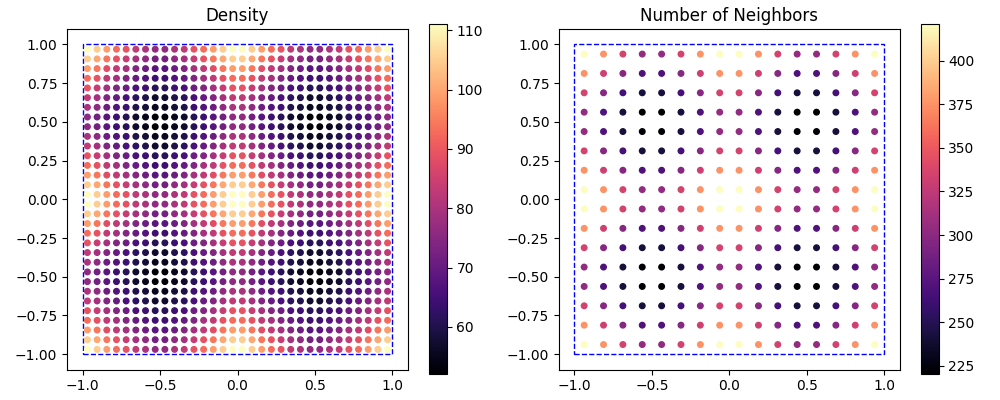

In [6]:
fig, axis = plt.subplots(1,2 , figsize=(10,4), squeeze=False)
markerSize = 16
visualizeParticles(fig, axis[0,0], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleStateLR, config['domain'], numNeighborsLR,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [7]:
from ml import *

In [8]:
inputFeatures = torch.cat([
    particleState.velocities,
    torch.ones_like(particleState.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

inputFeaturesLR = torch.cat([
    particleStateLR.velocities,
    torch.ones_like(particleStateLR.velocities[:, 0])[:, None],  # bias term
], dim = 1).to(device)

gt = particleState.densities.to(device)[:, None]  # ground truth densities

In [9]:
latentSpaceSize = 17
hiddenMLPSize = 61
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

In [10]:
# inputEncoder = buildMLPwDict({
#  'inputFeatures': inputFeatures.shape[1],
#  'output' : 48,
#  'activation': 'celu',
#  'layout': [hiddenMLPSize] * inputEncoderLayers,
#  'norm': False,
#  'bias': False,
# }
# ).to(device)

# numberOfParameters = sum(p.numel() for p in inputEncoder.parameters())
# print(f'Number of parameters in input encoder: {numberOfParameters}')

# for i, layer in enumerate(inputEncoder):
#     print(f'Layer {i}: {layer}')

# encodedInput = inputEncoder(inputFeatures)
# encodedInputLR = inputEncoder(inputFeaturesLR)

In [11]:
from diffSPH.neighborhood import computeSparseDistanceTensor, filterNeighborhood, SparseNeighborhood, NeighborhoodInformation

# @torch.jit.script
def filterNeighborhood(neighborhood: SparseNeighborhood, mode: str = 'superSymmetric'):
    if isinstance(neighborhood, NeighborhoodInformation):
        raise ValueError('Cannot filter neighborhood with NeighborhoodInformation')

    # adjacency = neighborhood.fullAdjacency
    row, col = neighborhood.row, neighborhood.col
    rij, xij = computeSparseDistanceTensor(neighborhood, normalize = True, mode = mode)
    mask = rij <= 1
    # print(mask)
    # print(rij, 'max: ', rij.max().item())
    # print(torch.sum(mask).item(), 'out of', rij.shape[0], 'edges kept')
    return SparseNeighborhood(row[mask], col[mask], numRows = neighborhood.numRows, numCols = neighborhood.numCols,
                                points_a = neighborhood.points_a, points_b = neighborhood.points_b,
                                domain = neighborhood.domain)


print(neighbors.neighbors.row.shape)
filteredNeighborhood = filterNeighborhood(neighbors.neighbors, mode = 'gather')
# filteredNeighborhood = neighbors.neighbors

print(filteredNeighborhood.row.shape)


h_i = particleState.supports[filteredNeighborhood.row].to(device)
rij, xij_ = computeSparseDistanceTensor(filteredNeighborhood, normalize = False)
sparse_edge_attr = xij_ / h_i[:,None]

print('Maximum distance: ', (rij / h_i).max().item())


# minD = domain.min
# maxD = domain.max
# periodicity = domain.periodic

# dense_xij = (particleState.positions[:,None] - particleState.positions)
# dense_mod_xij = torch.stack([dense_xij.reshape(nx**4, 2)[:,i] if not periodic_i else mod(dense_xij.reshape(nx**4, 2)[:,i], minD[i], maxD[i]) for i, periodic_i in enumerate(periodicity)], dim = -1).reshape(nx**2, nx**2, dim)

# print('dense_xij', dense_mod_xij.shape)
# print(dense_mod_xij.min())

torch.Size([78160])
torch.Size([16256])
Maximum distance:  0.9519716501235962


In [12]:
torch.cuda.empty_cache()

In [13]:
from util import *
# adjacency = buildDenseNeighborhood(particleState, domain)
adjacency = buildSparseNeighborhood(filteredNeighborhood)

In [14]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [15]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency, normalize = False, mode = 'gather')

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 11
multiHeads = 3
batch_size = 1
num_nodes = inputFeatures.shape[0]
latentSpaceSize = 17
dim = edge_attr.shape[-1]

node_attr = (inputFeatures.reshape(1, -1, inputFeatures.shape[-1]), inputFeaturesLR.reshape(1, -1, inputFeaturesLR.shape[-1]))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 5
node_attr_batched = (inputFeatures.repeat(bs, 1, 1), inputFeaturesLR.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleStateLR.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

edge_attr shape: torch.Size([16256, 2])
edge_index shape: torch.Size([2, 16256])
node_attr shape: torch.Size([1, 1024, 3]) torch.Size([1, 256, 3])
Edge indices for batch 0: torch.Size([2, 16256])
Edge indices for batch 1: torch.Size([2, 16256])
Edge indices for batch 2: torch.Size([2, 16256])
Edge indices for batch 3: torch.Size([2, 16256])
Edge indices for batch 4: torch.Size([2, 16256])
node_attr_batched shape: torch.Size([5, 1024, 3]) torch.Size([5, 256, 3])
edge_attr_batched shape: torch.Size([81280, 2])
edge_indices_batched shape: torch.Size([2, 81280])


In [16]:
from layers.layer_inputEncoder import InputEncodeLayer

inputEncoder = InputEncodeLayer(
    input_dim = inputFeatures.shape[-1],
    output_dim = latentSpaceSize,
    spatial_dim = edge_attr.shape[-1],

    linearEncode = False,
    encoderMLPDict = None,

    absolutePositionBias = True,
    absolutePositionBiasScaledPositions = False,
    absolutePositionBiasMultiplicative = False,

    absolutePositionBiasBaseEncoding = True,
    absolutePositionBiasBaseFunction = 'ffourier',
    absolutePositionBiasBaseTerms = 8,
    absolutePositionBiasBaseMode = 'cat',

    absolutePositionBiasLinear = True,
    absolutePositionBiasMLPDict = None,

    verbose = True).to(device)


inputEncoderNumFeatures = count_parameters(inputEncoder)
print(f'Number of parameters in Input Encoder: {inputEncoderNumFeatures}')


Initializing Input Encode Layer...
	Dimensions: input_dim=3, output_dim=17, spatial_dim=2
	Input feature encoding: linearEncode=False
	Input feature encoding: encoderMLPDict={'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Absolute Position Bias (APB): absolutePositionBias=True
	Absolute Position Bias (APB): absolutePositionBiasScaledPositions=False
	Absolute Position Bias (APB): absolutePositionBiasMultiplicative=False
	Absolute Position Bias (APB): absolutePositionBiasBaseEncoding=True
	Absolute Position Bias (APB): absolutePositionBiasBaseFunction=ffourier
	Absolute Position Bias (APB): absolutePositionBiasBaseTerms=8
	Absolute Position Bias (APB): absolutePositionBiasBaseMode=cat
	Absolute Position Bias (APB): absolutePositionBiasLinear=True
	Absolute Position Bias (APB): absolutePositionBiasMLPDict={'layout': [64, 64], 'activation': 'celu', 'norm

In [17]:
print(f'Node attr shape: {node_attr_batched[0].shape}')
inputEncoded = inputEncoder(node_attr_batched[0], particleState.positions)
print(f'Input Encoded shape: {inputEncoded.shape}')

Node attr shape: torch.Size([5, 1024, 3])
Running Input Encode Layer...
	Input tokens shape: torch.Size([5, 1024, 3])
	Input positions shape: torch.Size([1024, 2])
	Encoding input features...
	Encoded features shape: torch.Size([5, 1024, 17])
	Encoding absolute position bias (APB)...
	Passing encoded positions through APB encoder
	APB shape: torch.Size([1024, 17])
	Using additive APB
	Features shape after adding APB: torch.Size([5, 1024, 17])
Done running Input Encode Layer.
Input Encoded shape: torch.Size([5, 1024, 17])


In [18]:
print(f'Node attr LR shape: {node_attr_batched[1].shape}')
inputEncodedLR = inputEncoder(node_attr_batched[1], particleStateLR.positions)
print(f'Input LR Encoded shape: {inputEncodedLR.shape}')

Node attr LR shape: torch.Size([5, 256, 3])
Running Input Encode Layer...
	Input tokens shape: torch.Size([5, 256, 3])
	Input positions shape: torch.Size([256, 2])
	Encoding input features...
	Encoded features shape: torch.Size([5, 256, 17])
	Encoding absolute position bias (APB)...
	Passing encoded positions through APB encoder
	APB shape: torch.Size([256, 17])
	Using additive APB
	Features shape after adding APB: torch.Size([5, 256, 17])
Done running Input Encode Layer.
Input LR Encoded shape: torch.Size([5, 256, 17])


In [19]:
from layers.layer_attentionMechanism import AttentionMechanismLayer

attentionMechanism = AttentionMechanismLayer(
                    latent_dim = latentSpaceSize,
                    transformer_features= transformerFeatures,
                    edge_dim = edge_attr.shape[-1],
                    num_heads = multiHeads,

                    attentionMechanism = 'linear',
                    attentionScoreMLPDict = None,
                    attentionDropout = 0.0,
                    attentionScaling = True,
                    attentionActivation = 'leaky_relu(0.2)',

                    encodeTokens = True,
                    encodeTokensLinear = True,
                    encodeTokensMLPDict = None,
                    encodeTokensShared = False,
                    cConvMode = False,

                    relativePositionBias = True,
                    relativePositionBiasSplit=True,
                    relativePositionBiasAfterAttention= True,
                    relativePositionBiasScaledPositions = False,
                    relativePositionBiasMultiplicative = False,
                    relativePositionBiasBaseEncoding = True,
                    relativePositionBiasBaseFunction = 'ffourier',
                    relativePositionBiasBaseTerms = 8,
                    relativePositionBiasBaseMode = 'cat',
                    relativePositionBiasEncoder = True,
                    relativePositionBiasLinear = True,
                    relativePositionBiasMLPDict = None,

                    windowFunction = False,
                    windowFunctionType = 'cubicSpline',
                    windowFunctionBeforeSoftmax = True,

                    skipSoftmax = False,

                    verbose = True).to(device)

attentionMechanismNumFeatures = count_parameters(attentionMechanism)
print(f'Number of parameters in Attention Mechanism: {attentionMechanismNumFeatures}')

Initializing Attention Mechanism Layer with parameters:
	Latent dimension: 17
	Edge dimension: 2
	Transformer dimension: 11
	Number of heads: 3
	Attention Mechanism: linear
	Attention Score MLP Dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Attention Dropout: 0.0
	Attention Scaling: True
	Attention Clipping: False
	Attention Activation: leaky_relu with arguments (0.2,)
	Skip Softmax: False
	Encode Tokens: True
	Encode Tokens Linear: True
	Encode Tokens MLP Dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Encode Tokens Shared: False
	Using continuous Convolution Mode: False
	Relative Position Bias: True
		Relative Position Bias Scaled Positions: False
		Relative Position Bias Multiplicative: False
		Rela

In [20]:
attentionValues = attentionMechanism(
    queryTokens = inputEncoded,
    keyTokens = inputEncodedLR,
    edge_index = edge_indices_batched,
    edge_attr = edge_attr_batched,
    edge_scaling = None, #torch.linalg.norm(edge_attr_batched * particleState.supports[edge_indices_batched[0]].view(-1,1), dim = -1),
    s_k = None)

print(f'Attention Values shape: {attentionValues.shape}')

#                     Running Attention Mechanism Layer...                     #
	Query tokens shape: torch.Size([5, 1024, 17]) [B, Q, L]
	Key tokens shape: torch.Size([5, 256, 17]) [B, K, L]
	Edge index shape: torch.Size([2, 81280]) [2, E]
	Edge attr shape: torch.Size([81280, 2]) [E, D]
	Edge scaling shape: None [E]
	S_k shape: None [B,K]
	Input Shapes: [B, Q, K, L, D, E] = [5, 1024, 256, 17, 2, 81280]
	Transformer Shapes: [H, T, T*H] = [3, 11, 33]
#             Encoding Edge Attributes for Relative Position Bias              #
	Encoding Relative Position Bias (RPB)...
		RPB basis function encoding output shape: torch.Size([81280, 3])
		RPB encoded features shape: torch.Size([81280, 3]) [E, H * T]
		RPB reshaped features shape: torch.Size([1, 81280, 3]) [1, E, H]
#                      	Encoding Query and Key Tokens...                       #
Input Token Shape [current ]: torch.Size([5, 1024, 17]) [B 5 x N 1024 x D 17]
Input Token Shape [neighbor]: torch.Size([5, 256, 17]) [B 5 x N 25

In [21]:
from layers.layer_messagePassing import MessagePassingLayer

messagePassing = MessagePassingLayer(
    node_feature_dim = latentSpaceSize,
    transformer_features= transformerFeatures,
    edgeFeatureSize= 0,
    spatial_dim= dim,
    multi_heads = multiHeads,
    latent_dim= None,
    output_dim= latentSpaceSize,

    split_across_heads=True,
    message_mode = 'transformer',
    skipConnections = False,
    multiHeadAggregation = 'concat',

    use_input_proj=True,
    input_proj_linear=True,

    use_output_proj=True,
    output_proj_linear=True,

    relative_position_bias=True,
    rpb_base_encoding=True,
    rpb_base_basis='ffourier',
    rpb_base_terms=4,
    rpb_base_mode='cat',
    rpb_proj=False,
    rpb_split=True,
    rpb_dim= None,
    rpb_proj_linear=True,

    window_function = True,
    window_function_type = 'cubicSpline',
    window_function_normalize= True,

    edge_gating = True,
    edge_gating_repeat = True,
    edge_gating_edge_vectors = True,
    edge_gating_edge_features = False,
    edge_gating_rpb = True,

    verbose = True
).to(device)

#                       Initializing MessagePassingLayer                       #
Dimension Features:
	node_feature_dim: 17, transformer_features: 11, edgeFeatureSize: 0, spatial_dim: 2
	multi_heads: 3, latent_dim: 33, output_dim: 17
Architecture:
	split_across_heads: True, use_input_proj: True, use_output_proj: True, message_mode: transformer
	input_proj_linear: True, input_proj_mlp_dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	output_proj_linear: True, output_proj_mlp_dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1} multiHeadAggregation: concat, skipConnections: False
	message_activation: identity
Relative Position Bias:
	relative_position_bias: True, rpb_base_encoding: True, rpb_base_terms: 4, rpb_bas

In [22]:
messagePassing(
    queryTokens = inputEncoded,
    keyTokens = inputEncodedLR,
    edge_index = edge_indices_batched,
    edge_attr = None,
    edge_vector = edge_attr_batched,
    attention_values = attentionValues,
    S_k = None)

#                         MessagePassingLayer Forward                          #
Input Shapes:
	B: 5
	nQ: 1024
	nK: 256
	nE: 81280
	D: 2
	E: 0
	H: 3
	L: 33
	T: 11
	I: 17
	O: 17
	RPB: 8
	G: 11
	edge_index: torch.Size([2, 81280])
	edge_attr: None
	edge_vector: torch.Size([81280, 2])
	attention_values: torch.Size([3, 81280])
	S_k: None
#                               Projection Step                                #
Query Tokens: torch.Size([5, 1024, 17]) [B, nQ, I] -> torch.Size([5, 1024, 33]) [B, nQ, L]
Key Tokens: torch.Size([5, 256, 17]) [B, nK, I] -> torch.Size([5, 256, 33]) [B, nK, L]
Reshaped Query Tokens for multi-head: torch.Size([5, 1024, 3, 11]) [B, nQ, H, T]
Reshaped Key Tokens for multi-head: torch.Size([5, 256, 3, 11]) [B, nK, H, T]
Final Query Tokens for multi-head: torch.Size([3, 5120, 11]) [H, B*N, T]
Final Key Tokens for multi-head: torch.Size([3, 1280, 11]) [H, B*M, T]
#                                 Gather Step                                  #
Gathered Node Features

tensor([[[-0.1061, -0.1683,  0.0700,  ..., -0.1919,  0.0348, -0.1425],
         [-0.1069, -0.1546,  0.0605,  ..., -0.2101,  0.0351, -0.1374],
         [-0.0969, -0.1459,  0.0319,  ..., -0.2193,  0.0412, -0.1334],
         ...,
         [-0.0755, -0.1784,  0.0233,  ..., -0.2023,  0.0062, -0.1655],
         [-0.0938, -0.1764,  0.0533,  ..., -0.1891,  0.0161, -0.1574],
         [-0.1080, -0.1694,  0.0786,  ..., -0.1980,  0.0163, -0.1478]],

        [[-0.1061, -0.1683,  0.0700,  ..., -0.1919,  0.0348, -0.1425],
         [-0.1069, -0.1546,  0.0605,  ..., -0.2101,  0.0351, -0.1374],
         [-0.0969, -0.1459,  0.0319,  ..., -0.2193,  0.0412, -0.1334],
         ...,
         [-0.0755, -0.1784,  0.0233,  ..., -0.2023,  0.0062, -0.1655],
         [-0.0938, -0.1764,  0.0533,  ..., -0.1891,  0.0161, -0.1574],
         [-0.1080, -0.1694,  0.0786,  ..., -0.1980,  0.0163, -0.1478]],

        [[-0.1061, -0.1683,  0.0700,  ..., -0.1919,  0.0348, -0.1425],
         [-0.1069, -0.1546,  0.0605,  ..., -0

In [23]:
from transformer import *

denseNodeTransformer = TransformerLayer(
    latentSpaceSize, transformerFeatures, dim, multiHeads,
    edge_bias = True, edge_gating = True, verbose = False, attentionOp = 'dot', attentionOpIncludeEdge = True, sharedWeights=False, headAggregation='mean', v2 = False).to(device)

num_parameters = sum(p.numel() for p in denseNodeTransformer.parameters())
print(f"Number of parameters in denseNodeTransformer: {num_parameters}")
print(denseNodeTransformer)

Number of parameters in denseNodeTransformer: 4443
TransformerLayer(
  (W_Q): Linear(in_features=17, out_features=33, bias=False)
  (W_K): Linear(in_features=17, out_features=33, bias=False)
  (W_V): Linear(in_features=17, out_features=33, bias=False)
  (W_E): Linear(in_features=2, out_features=3, bias=True)
  (W_E_gate): Linear(in_features=2, out_features=33, bias=True)
  (activation): CELU(alpha=1.0)
  (W_O): Linear(in_features=11, out_features=17, bias=False)
  (layer_norm1): LayerNorm((17,), eps=1e-05, elementwise_affine=True)
  (layer_norm2): LayerNorm((17,), eps=1e-05, elementwise_affine=True)
  (ffn): Sequential(
    (0): Linear(in_features=17, out_features=68, bias=True)
    (1): CELU(alpha=1.0)
    (2): Linear(in_features=68, out_features=17, bias=True)
  )
  (attentionActivation): LeakyReLU(negative_slope=0.2)
)


In [27]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')

Transformer output shape: torch.Size([1, 1024, 48])


In [28]:
transformerOutput_batched = denseNodeTransformer(node_attr_batched, edge_attr_batched, edge_indices_batched)
print(f'Transformer output shape: {transformerOutput_batched.shape}')

Transformer output shape: torch.Size([4, 1024, 48])


In [29]:
print(transformerOutput[0])

tensor([[-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3587,  1.7507,  0.6306,  ...,  2.2106, -0.5155, -0.1989],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)


In [30]:
print(transformerOutput[0])
print(transformerOutput_batched[1])

print(torch.all(torch.isclose(transformerOutput[0], transformerOutput_batched[0], atol= 1e-6)))

diff = (transformerOutput[0] - transformerOutput_batched[0])
print(f'Difference: min: {diff.min()}, max: {diff.max()}, mean: {diff.mean()}')

tensor([[-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3558,  1.7523,  0.6287,  ...,  2.2088, -0.5195, -0.1962],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3587,  1.7507,  0.6306,  ...,  2.2106, -0.5155, -0.1989],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor([[-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        [-0.3555,  1.7527,  0.6280,  ...,  2.2095, -0.5207, -0.1979],
        ...,
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955],
        [-0.3555,  1.7525,  0.6284,  ...,  2.2107, -0.5206, -0.1955]],
       device='cuda:0', grad_fn=<SelectBackward0>)
tensor(False, device='cuda:0')

In [31]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency)

edge_attr = -xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.col, adjacency.row])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)

transformerFeatures = 16
multiHeads = 4
batch_size = 1
num_nodes = nx**2
latentSpaceSize = encodedInput.shape[-1]
dim = edge_attr.shape[-1]

node_attr = (encodedInputLR.reshape(1, -1, latentSpaceSize), encodedInput.reshape(1, -1, latentSpaceSize))  # Reshape to [B, N, F] for batch processing

print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)

bs = 4
node_attr_batched = (encodedInputLR.repeat(bs, 1, 1), encodedInput.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleStateLR.positions.shape[0]
    cumCols += particleState.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

edge_attr shape: torch.Size([53248, 2])
edge_index shape: torch.Size([2, 53248])
node_attr shape: torch.Size([1, 256, 48]) torch.Size([1, 1024, 48])
Edge indices for batch 0: torch.Size([2, 53248])
Edge indices for batch 1: torch.Size([2, 53248])
Edge indices for batch 2: torch.Size([2, 53248])
Edge indices for batch 3: torch.Size([2, 53248])
node_attr_batched shape: torch.Size([4, 256, 48]) torch.Size([4, 1024, 48])
edge_attr_batched shape: torch.Size([212992, 2])
edge_indices_batched shape: torch.Size([2, 212992])


In [32]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')

Transformer output shape: torch.Size([1, 256, 48])
